# Simulation guidelines

What the simulated control loop must reproduce of the real one, so that the policy trained in MuJoCo transfers to the robot:

- **Control rate:** step the policy at about 20 Hz and run the physics at 500–1000 Hz underneath, as the real loop runs at about 22 Hz.
- **Latency:** there's roughly one frame between capturing an image and moving the servos, so add a 1–2 step delay on the observation or action.
- **Observations:** the policy gets the error in pixels from a 320×240 frame, with noise. It measures position only, so give it the last few errors and actions, or a finite-difference velocity like the PID and LQR use.
- **Servos:** SG90s are slow and have a deadband. Model them as a rate limit or first-order lag, plus the clipping to 45–75°.
- **Losing the ball:** end the episode when the ball leaves the plate or goes out of the camera's view.
- **Ball physics:** a ping pong ball is a hollow shell, but MuJoCo assumes a solid sphere. Set its inertia explicitly ($I = \frac{2}{3} m R^2$), use `condim="6"` so rolling friction is modeled, and set the mass to about 2.7 g.
- **Domain randomization:** vary friction, mass, latency, servo speed, sensor noise and a small tilt bias. The servo horns can only be fitted every 18° and are corrected by hand-tuned offsets, so the real plate is never exactly level at the nominal pose.

# Environment

The environment is `BallBalancerEnv` in `ball_balancer_env.py`, a Gymnasium `MujocoEnv` built on the model `ball_balancer.xml`.

The policy only has to stabilize the ball: the kinematics is already known, so the action is the slope $\mathbf{u}$ of the plate, the same quantity returned by `control.pid` and `control.lqr`. Everything after it is the chain that runs on the robot:

$$\mathbf{u} \rightarrow \texttt{kinematics.solve} \rightarrow \text{clip to } [45°,\ 75°] \rightarrow \text{servos} \rightarrow \text{plate pose}$$

- **Action**: $\mathbf{a} \in [-1, 1]^2$, with $\mathbf{u} = 0.2\ \mathbf{a}$: a slope of 0.2 is the largest the servos can reach in every direction.
- **Plate**: the three arms are not simulated. The servo angles are turned back into the pose of the plate by the forward kinematics, solved numerically on `kinematics.solve`, and the plate is driven kinematically through a slide and two hinges.
- **Servos**: first order lag with a rate limit and a deadband, on each servo angle, plus a residual offset of the horns.
- **Observation**: the last 3 pixel errors of the ball (frame centre minus ball, scaled by 160 px), delayed and noisy, and the last 2 actions.
- **Episode**: it ends when the ball leaves the 320×240 frame, or after 440 steps, about 20 s.
- **Reward**: $1 - \lVert \mathbf{p} \rVert / 120\,\text{px} - 0.05 \lVert \mathbf{a} \rVert^2 - 0.1 \lVert \mathbf{a} - \mathbf{a}_{prev} \rVert^2$.

The nominal values of the physical parameters and their randomization ranges are `NOMINAL` and `RANDOM` in `ball_balancer_env.py`. The domain randomization is on by default, `randomize=False` uses the nominal values.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

# the kernel may start in the repository root or in this folder, depending on how Jupyter was launched
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts" / "control.py").exists())
RL_DIR = ROOT / "reinforcement_learning"
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(RL_DIR))

import control          # the PID and LQR that run on the robot

from ball_balancer_env import BallBalancerEnv, ERR_SCALE, U_MAX

In [2]:
env = BallBalancerEnv()
obs, info = env.reset(seed=0)

# Display basic information about the environment
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Control period:", info["dt"], "s")
print("Parameters of this episode:")
for k, v in info["params"].items():
    print(f"  {k}: {np.round(v, 6)}")

env.close()

Observation space: Box(-inf, inf, (10,), float32)
Action space: Box(-1.0, 1.0, (2,), float32)
Control period: 0.046 s
Parameters of this episode:
  substeps: [20 27]
  latency: 0.045478
  noise_px: 0.90468
  servo_tau: 0.016024
  servo_speed: 304.958291
  deadband: 0.81327
  q_offset: [1.651022 0.426543 0.917986]
  cam_yaw: 0.43625
  cam_offset: [4.350724 3.158536]
  px_per_m: 2251.36925
  ball_mass: 0.002843
  slide_friction: 0.220151
  roll_friction: 3.6e-05


# Episode Visualization

An episode can be run with random actions, or with the PID and the LQR of `scripts/control.py`, unchanged, as expert policies. They receive the same delayed and noisy error that the policy will observe, and the measured control period.

In [3]:
def act(policy, obs, info):
    # the error measured by the camera, in pixels
    err = obs[:2] * ERR_SCALE
    if policy == "random":
        return env.action_space.sample()
    if policy == "pid":
        u = control.pid(err, info["dt"])
    elif policy == "lqr":
        u = control.lqr(err, info["dt"])
    return np.clip(u / U_MAX, -1, 1)


def run_episode(env, policy, seed=None, record=False):
    obs, info = env.reset(seed=seed)
    control.reset(info["err"])          # as on the robot when the ball is acquired
    frames, ball_px, rewards = [], [], []
    while True:
        obs, reward, terminated, truncated, info = env.step(act(policy, obs, info))
        ball_px.append(info["ball_px"])
        rewards.append(reward)
        if record:
            frames.append(env.render())
        if terminated or truncated:
            print(f"{policy}: {'Terminated, ball lost' if terminated else 'Truncated'} after {len(rewards)} steps, return {sum(rewards):.1f}")
            break
    return frames, np.array(ball_px), np.array(rewards)

## Launching the MuJoCo Simulator

In [4]:
# Flag to choose the policy: "random", "pid" or "lqr"
policy = "pid"

# Create the environment with rendering enabled
env = BallBalancerEnv(render_mode="human")

run_episode(env, policy, seed=0)

env.close()

pid: Truncated after 440 steps, return 403.1


## Saving a GIF

The cameras of the model are `side`, and `below`, which looks up at the plate as the camera of the robot.

## Checking the simulation with the PID and the LQR

If the gains that balance the ball on the robot balance it in simulation too, and in a similar way, the simulation is credible. The plot shows the distance of the ball from the centre of the frame, with the same initial condition for every policy.

random: Terminated, ball lost after 13 steps, return 3.1
pid: Truncated after 440 steps, return 418.2
lqr: Truncated after 440 steps, return 395.1


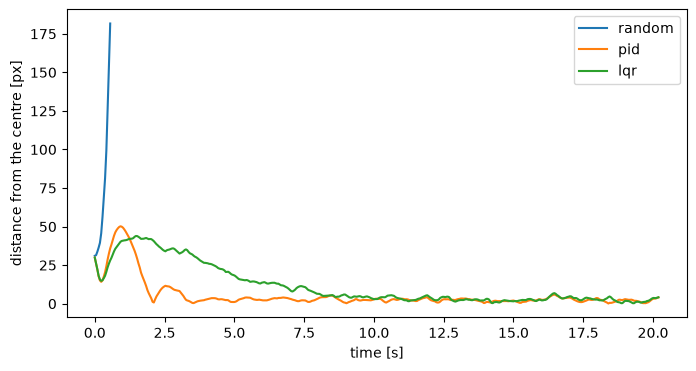

In [5]:
env = BallBalancerEnv()

fig, ax = plt.subplots(figsize=(8, 4))
for policy in ["random", "pid", "lqr"]:
    _, ball_px, _ = run_episode(env, policy, seed=1)
    t = np.arange(len(ball_px)) * env.dt
    ax.plot(t, np.linalg.norm(ball_px, axis=1), label=policy)

env.close()

ax.set_xlabel("time [s]")
ax.set_ylabel("distance from the centre [px]")
ax.legend()
plt.show()

# Reinforcement Learning policy

In [7]:
import gymnasium as gym

from stable_baselines3 import A2C

env = gym.make("CartPole-v1", render_mode="rgb_array")
model = A2C("MlpPolicy", env, verbose=0)

model.learn(total_timesteps=100_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 25.8     |
|    ep_rew_mean        | 25.8     |
| time/                 |          |
|    fps                | 1422     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.683   |
|    explained_variance | -0.00937 |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 1.47     |
|    value_loss         | 8.11     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 29       |
|    ep_rew_mean        | 29       |
| time/                 |          |
|    fps                | 1623     |
|    iterations         | 200      |
|    time_elapsed 

In [8]:
# watch the trained policy in a pygame window. VecEnv.render("human") would need OpenCV,
# whose SDL2 clashes with the one of pygame
env = gym.make("CartPole-v1", render_mode="human")
obs, _ = env.reset()
for i in range(10_000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, _ = env.reset()
env.close()